**2. MOCO TRAINING**

In [3]:
import digitalhub as dh
import pandas as pd
import matplotlib.pyplot as plt

NOME_PROGETTO = "floods"
project = dh.get_project(NOME_PROGETTO)
print(f"Progetto: {project.name}")

UnauthorizedError: Unauthorized. Response: .

**SETUP PARAMETERS**

In [1]:
# Parametri job
job_name = "debug_v1"                                  # nome da passare poi a notebook moco 
dataset = "Test"    
epochs = 10                                # Test, Standard, Anomalies*
weights_encoder_sar = "train_s1_v1"     
weights_encoder_opt = "Standard_train_s2_v3"                
#handler = pretrain_encoders                        

parametri = {
    "epochs": epochs, 
    "batch_size": 16,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "momentum": 0.9,
    "patch_size": 256,
    "n_images1": 4, "n_channels1": 2,               # sar
    "n_images2": 4, "n_channels2": 10,              # ottico
    "moco_dim": 128,
    "moco_k": 64,                                 # dimensioni coda (multiplo batch_size),  standard: 1554, test: 64   
    "moco_t": 0.07,
    "symmetric": False,
    "mamba": False,
    "workers": 0,
    "job_name": job_name,
    "dataset": dataset,
    "weights_encoder_sar": weights_encoder_sar,
    "weights_encoder_opt": weights_encoder_opt,
    "patience": 20,
    "min_delta": 1e-4,
    "time_debug": True                             # time_debug = True solo per debug, = False per training  
}

print(f"PARAMETRI: {parametri}")

# volume
volumi = [
    {
        "volume_type": "ephemeral",
        "name": "volume-spazio-dati",
        "mount_path": "/data",      
        "spec": {"size": "500Gi"}   
    }
]



PARAMETRI: {'epochs': 10, 'batch_size': 16, 'lr': 0.001, 'weight_decay': 0.0001, 'momentum': 0.9, 'patch_size': 256, 'n_images1': 4, 'n_channels1': 2, 'n_images2': 4, 'n_channels2': 10, 'moco_dim': 128, 'moco_k': 64, 'moco_t': 0.07, 'symmetric': False, 'mamba': False, 'workers': 0, 'job_name': 'debug_v1', 'dataset': 'Test', 'weights_encoder_sar': 'train_s1_v1', 'weights_encoder_opt': 'Standard_train_s2_v3', 'patience': 20, 'min_delta': 0.0001, 'time_debug': True}


**BUILD ENVIRONMENT**

In [20]:
moco_func = project.new_function(
    name= f'moco_Floods_{dataset}_{job_name}_{epochs}',
    kind="python",
    python_version="PYTHON3_10",
    code_src="../src/", 
    handler="train_moco", 
    base_image="pytorch/pytorch:2.1.2-cuda11.8-cudnn8-runtime",
    requirements=["pandas==2.3.3", "numpy==1.26.4", "rasterio==1.4.4", "tqdm==4.70.0", "tifffile==2024.8.30"]
)



# .run("build") -> scarica immagine, installa requirements, copia intera cartella code_src, crea immagine docker

build = moco_func.run("build", wait=True)
print(f"BUILD: {build.status.state}")

2026-08-26 13:57:07,987 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 4bf60758b9b84187b7c67de92b0b3840 to finish...
2026-08-26 13:57:12,998 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 4bf60758b9b84187b7c67de92b0b3840 to finish...
2026-08-26 13:57:18,013 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 4bf60758b9b84187b7c67de92b0b3840 to finish...
2026-08-26 13:57:23,026 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 4bf60758b9b84187b7c67de92b0b3840 to finish...
2026-08-26 13:57:28,046 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 4bf60758b9b84187b7c67de92b0b3840 to finish...
2026-08-26 13:57:33,060 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 4bf60758b9b84187b7c67de92b0b3840 to finish...
2026-08-26 13:57:38,074 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 4bf60758b9b84187b7c67de92b0b3840 to finish...
2026-08-26 13

BUILD: COMPLETED


**TRAINING**

In [21]:
# action job = avvia container, esegue script, libera risorse

run_moco = moco_func.run(
    action="job", 
    parameters=parametri, 
    volumes=volumi, 
    profile="1xV100",
    # local_execution= True,                       # 1x = 1 gpu
    wait=True
)

print(f"Run moco avviato: {run_moco.id}")
print(run_moco.status.state)
print(run_moco.status.message)

2026-08-26 13:57:58,531 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run a36d18919cfa4d6ea89ffd459840dc5d to finish...
2026-08-26 13:58:03,543 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run a36d18919cfa4d6ea89ffd459840dc5d to finish...
2026-08-26 13:58:08,556 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run a36d18919cfa4d6ea89ffd459840dc5d to finish...
2026-08-26 13:58:13,568 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run a36d18919cfa4d6ea89ffd459840dc5d to finish...
2026-08-26 13:58:18,685 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run a36d18919cfa4d6ea89ffd459840dc5d to finish...
2026-08-26 13:58:23,800 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run a36d18919cfa4d6ea89ffd459840dc5d to finish...
2026-08-26 13:58:28,916 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run a36d18919cfa4d6ea89ffd459840dc5d to finish...
2026-08-26 13

Run moco avviato: a36d18919cfa4d6ea89ffd459840dc5d
COMPLETED
None


**PLOTS**

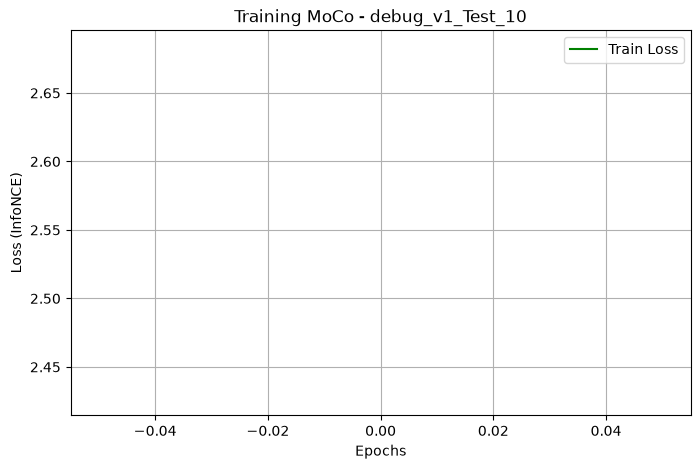

In [22]:
# salvataggio log
path_moco = project.get_artifact(f"moco-metrics_{job_name}_{dataset}_{epochs}").download(overwrite=True)
df_moco = pd.read_csv(path_moco)

# plot
plt.figure(figsize=(8, 5))
plt.plot(df_moco['epoch'], df_moco['train_loss'], color='green', label='Train Loss')
plt.title(f'Training MoCo - {job_name}_{dataset}_{epochs}')
plt.xlabel('Epochs')
plt.ylabel('Loss (InfoNCE)')
plt.grid(True)
plt.legend()
plt.show()